In [1]:
import os
home = os.environ['HOME']
run_path = os.path.join(home, 'far/farMe/close/test_iaw')

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pyphare
import pyphare.pharesee as phc
from pyphare.pharesee.run import Run

In [115]:
run  = Run(run_path)
L = 160
k = 2*np.pi/160

In [116]:
from pyphare.pharesee.hierarchy.fromh5 import get_times_from_h5
file = os.path.join(run_path, "ions_charge_density.h5")
times = get_times_from_h5(file)
print(times)
# times = np.arange(0, 41, 2)

[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 22. 24. 26. 28. 30. 32. 34.
 36. 38. 40.]


In [117]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

<class 'pyphare.core.box.Box'>
Box([0],[799])
1
<class 'pyphare.core.box.Box'>
Box([0],[799])
1
<class 'pyphare.core.box.Box'>
Box([0],[799])
1


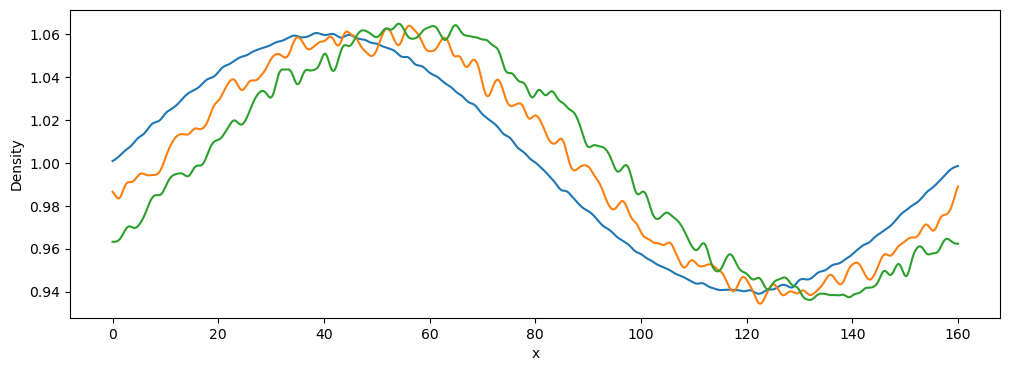

In [118]:
fig, ax = plt.subplots(figsize=(12,4))

for i, time in enumerate(times[::10]):
    N = run.GetNi(time)
    n = phc.filters.gaussian(N, sigma=4)
    n.plot(qty='value', ax=ax, ls='solid', lw=2.0, color=colors[i%10], ylabel='Density')

In [119]:
from scipy.optimize import curve_fit
def sine_func(x, A, B, C):
    L = 160
    k = 2*np.pi/L
    return A * np.sin(k * x + B) + C

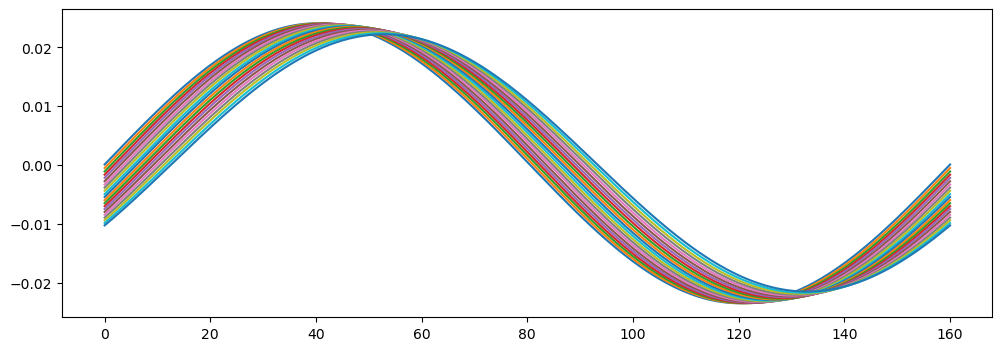

In [120]:
from pyphare.pharesee.hierarchy import uniformgrid as uniform

n1_far = np.zeros(times.shape)
f1_far = np.zeros(times.shape)

fig, ax = plt.subplots(figsize=(12,4))

for i, tim in enumerate(times[::]):
    # N = run.GetNi(tim, all_primal=False)
    V = run.GetVi(tim, all_primal=False)
    v = V.finest()
    v_grid = v['x']

    ghost_nb = v_grid.ghosts_nbr[0]
    x_ = v_grid.x[ghost_nb:-ghost_nb]
    w_ = np.asarray(v_grid[ghost_nb:-ghost_nb])

    params, covariance = curve_fit(sine_func, x_, w_, p0=[0.02, 0.0, 0.0])

    n1_far[i] = np.fabs(params[0])
    f1_far[i] = np.fabs(params[1])
    # v.plot(qty='x', ax=ax, ls='solid', lw=2.0, color=colors[i], ylabel='X-velocity')
    ax.plot(x_, sine_func(x_, *params))

In [131]:
def lin_func(x, A, B):
    return A * x + B

params, covariance = curve_fit(lin_func, times, f1_far, p0=[0.0125, 0.0])
# plt.plot(times, f1_far)

In [132]:
gamma_e, gamma_i = 1, 3
Te, Ti = 0.1, 0.02
# cs = np.sqrt(gamma_e*Te+gamma_i*Ti)
cs = np.sqrt(gamma_e*Te)

vphi_num = params[0]/k
vphi_AI = cs

In [133]:
vphi_num

np.float64(0.3154406271971697)

In [134]:
vphi_AI

np.float64(0.31622776601683794)